In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('heart.csv')

print("Dataset Head:")
display(df.head())

print("\nDataset Info:")
df.info()

Dataset Head:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
# Separate target variable 'HeartDisease' from features
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

print(f"Categorical columns: {list(categorical_cols)}")
print(f"Numerical columns: {list(numerical_cols)}")

# Apply Label Encoding for specific columns if needed (e.g., if some object columns have ordinal meaning)
# For this dataset, we'll primarily use One-Hot Encoding for the 'sex' and 'cp' columns if they are treated as nominal

# Apply One-Hot Encoding to categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("\nFeatures after One-Hot Encoding:")
display(X_encoded.head())

# Apply StandardScaler to numerical columns
scaler = StandardScaler()
X_scaled = X_encoded.copy()

# Only scale columns that are numerical after encoding (including the original numerical ones and new one-hot encoded ones)
columns_to_scale = X_scaled.columns
X_scaled[columns_to_scale] = scaler.fit_transform(X_scaled[columns_to_scale])

print("\nFeatures after Scaling:")
display(X_scaled.head())

Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numerical columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

Features after One-Hot Encoding:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,True,False,True,False,True,False,False,False,True



Features after Scaling:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.410909,0.825070,-0.551341,1.382928,-0.832432,0.515952,2.075177,-0.532838,-0.229679,0.814275,-0.490449,-0.823556,-1.002181,1.150674
1,-0.478484,1.491752,-0.171961,-0.551341,0.754157,0.105664,-1.938163,-0.481887,1.876744,-0.229679,0.814275,-0.490449,-0.823556,0.997824,-0.869056
2,-1.751359,-0.129513,0.770188,-0.551341,-1.525138,-0.832432,0.515952,2.075177,-0.532838,-0.229679,-1.228087,2.038947,-0.823556,-1.002181,1.150674
3,-0.584556,0.302825,0.139040,-0.551341,-1.132156,0.574711,-1.938163,-0.481887,-0.532838,-0.229679,0.814275,-0.490449,1.214246,0.997824,-0.869056
4,0.051881,0.951331,-0.034755,-0.551341,-0.581981,-0.832432,0.515952,-0.481887,1.876744,-0.229679,0.814275,-0.490449,-0.823556,-1.002181,1.150674


In [ ]:
# Split the preprocessed data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

# Initialize and train models
models = {
    'SVM': SVC(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Random Forest': RandomForestClassifier(random_state=42)
}

accuracy_results = {}

print("\nTraining and evaluating models without PCA:")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")

print("\nBest model without PCA:")
best_model_no_pca = max(accuracy_results, key=accuracy_results.get)
print(f"The best model is {best_model_no_pca} with an accuracy of {accuracy_results[best_model_no_pca]:.4f}")

Training features shape: (734, 15)
Testing features shape: (184, 15)

Training and evaluating models without PCA:
SVM Accuracy: 0.8750
Logistic Regression Accuracy: 0.8533
Random Forest Accuracy: 0.8750

Best model without PCA:
The best model is SVM with an accuracy of 0.8750


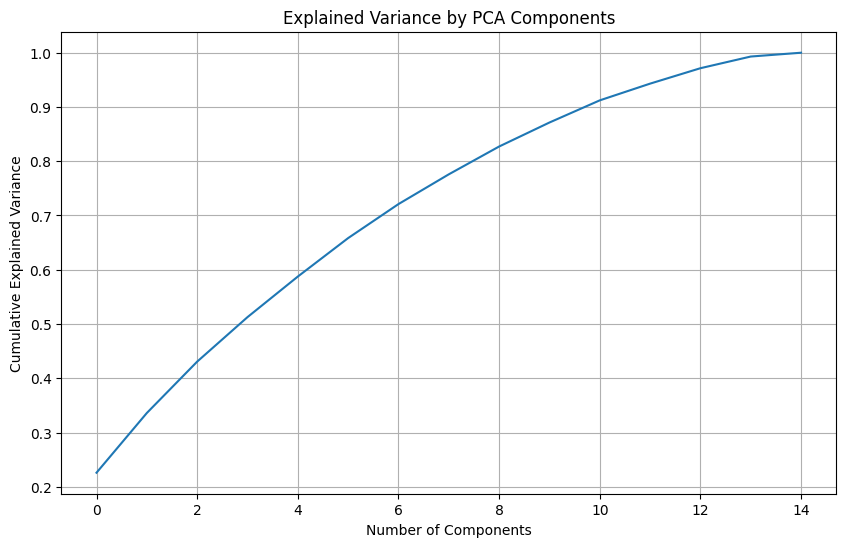

Original number of features: 15
Reduced number of features (PCA): 5
Total explained variance by 5 components: 0.5874

Training and evaluating models with PCA:
SVM Accuracy (with PCA): 0.8424
Logistic Regression Accuracy (with PCA): 0.8207
Random Forest Accuracy (with PCA): 0.8424

Best model with PCA:
The best model with PCA is SVM with an accuracy of 0.8424

--- Comparison of Accuracies ---
SVM:
  Without PCA: 0.8750
  With PCA:    0.8424
Logistic Regression:
  Without PCA: 0.8533
  With PCA:    0.8207
Random Forest:
  Without PCA: 0.8750
  With PCA:    0.8424

As observed, PCA can sometimes reduce accuracy, but it significantly reduces the number of features, leading to lighter computation. This is a common trade-off to consider in real-world model building.


In [ ]:
# Apply PCA
# Let's determine the number of components to keep, aiming for 95% explained variance
pca = PCA().fit(X_scaled)
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()

# Choose a number of components, e.g., components that explain 95% of the variance
# Or, for demonstration, let's just pick a reasonable number like 5 components
# You can adjust `n_components` based on the plot above.
n_components = 5 # Example: adjust this based on the plot for desired explained variance
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Reduced number of features (PCA): {X_pca.shape[1]}")
print(f"Total explained variance by {n_components} components: {pca.explained_variance_ratio_.sum():.4f}")

# Split PCA-transformed data into training and testing sets
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

accuracy_results_pca = {}

print("\nTraining and evaluating models with PCA:")
for name, model in models.items():
    # Re-initialize models to ensure fresh training
    if name == 'SVM':
        model_pca = SVC(random_state=42)
    elif name == 'Logistic Regression':
        model_pca = LogisticRegression(random_state=42, solver='liblinear')
    else:
        model_pca = RandomForestClassifier(random_state=42)

    model_pca.fit(X_train_pca, y_train_pca)
    y_pred_pca = model_pca.predict(X_test_pca)
    accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)
    accuracy_results_pca[name] = accuracy_pca
    print(f"{name} Accuracy (with PCA): {accuracy_pca:.4f}")

print("\nBest model with PCA:")
best_model_pca = max(accuracy_results_pca, key=accuracy_results_pca.get)
print(f"The best model with PCA is {best_model_pca} with an accuracy of {accuracy_results_pca[best_model_pca]:.4f}")

print("\n--- Comparison of Accuracies ---")
for name in models.keys():
    print(f"{name}:")
    print(f"  Without PCA: {accuracy_results[name]:.4f}")
    print(f"  With PCA:    {accuracy_results_pca[name]:.4f}")

print("\nAs observed, PCA can sometimes reduce accuracy, but it significantly reduces the number of features, leading to lighter computation. This is a common trade-off to consider in real-world model building.")